# 실습 4-3 : SVDD (Support Vector Data Description)

#### **<실습 내용>**

1. SVDD 개념 이해
- One-Class Learning 소개
- SVDD 원리

2. SVDD 모델 학습
- 정상 데이터만으로 Boundary 학습

3. 하이퍼 파라미터 (nu) 변화에 따른 영향
- 과적합 / 과소적합 확인

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day4-3_data.csv")
print("데이터 크기:", data.shape)
print()
print("클래스 분포:")
print(data["Y"].value_counts())
data.head()

데이터 크기: (100, 3)

클래스 분포:
Y
 1    50
-1    50
Name: count, dtype: int64


,0,1,Y
0,1.040235,-1.873163,1
1,-0.287562,3.278405,1
2,1.100316,3.462647,1
3,2.008401,0.555708,1
4,-0.968919,-2.632187,1


---

## 1) SVDD 개념

> **One-Class 모델**: 정상 데이터만 보고 정상 영역을 학습한 뒤, 그 영역을 벗어나면 이상치로 판단하는 기법
>
> **SVDD**: 정상 데이터를 감싸는 가장 작은 원(구) 모양의 경계를 만드는 방법
> - 중심과 반지름을 학습해서 정상 영역을 정의함
> - $C$ 값이 크면 오분류를 덜 허용해서 경계가 더 타이트해짐 (과적합 위험)
>
> sklearn의 `OneClassSVM`이 이 SVDD와 비슷한 방식의 모델임

### 1-1) 데이터 시각화

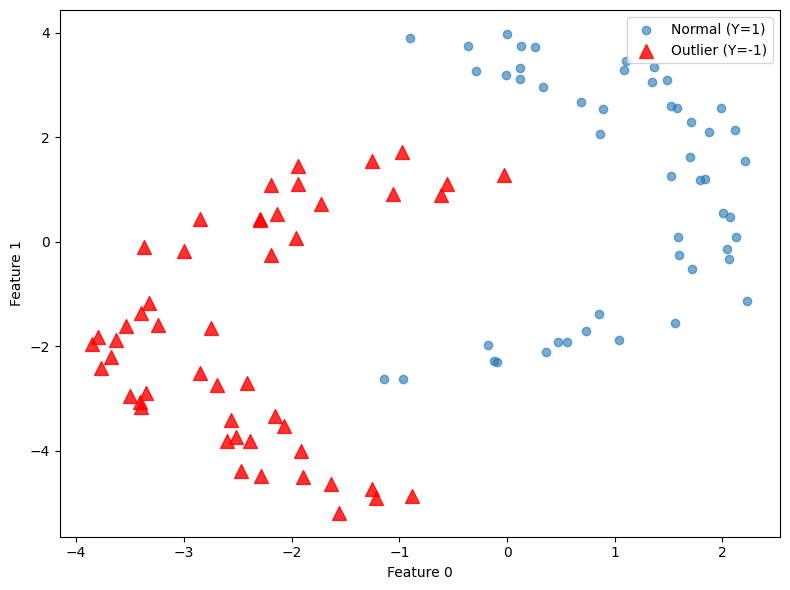

In [3]:
plt.figure(figsize=(8, 6))
normal = data[data["Y"] == 1]  # 정상 데이터만 추출
outlier = data[data["Y"] == -1]  # 이상치 데이터만 추출

plt.scatter(normal["0"], normal["1"], label="Normal (Y=1)", alpha=0.6)  # 정상 데이터 산점도
plt.scatter(outlier["0"], outlier["1"], label="Outlier (Y=-1)", marker="^", s=100, c="red", alpha=0.8)  # 이상치는 빨간 세모로 표시
plt.legend()
plt.xlabel("Feature 0"); plt.ylabel("Feature 1")
plt.tight_layout()
plt.show()

---

## 2) SVDD 모델 학습

> One-Class SVM은 **정상 데이터만으로** 학습함
> - `nu` 파라미터는 이상치 비율의 상한을 설정함 (SVDD의 $C$와 유사한 역할)
> - `kernel="rbf"`를 사용하면 비선형 Boundary를 학습함

### 2-1) 학습/테스트 데이터 분할

In [4]:
X = data[["0", "1"]]
Y = data["Y"]

# 정상 데이터만 추출하여 학습
X_normal = X[Y == 1]
X_outlier = X[Y == -1]

X_train, X_test_normal = train_test_split(X_normal, test_size=0.3, random_state=0)

# 테스트 데이터: 정상 + 이상치
X_test = pd.concat([X_test_normal, X_outlier])
Y_test = pd.Series([1] * len(X_test_normal) + [-1] * len(X_outlier))

print("학습 데이터 (정상만):", X_train.shape)
print("테스트 데이터:", X_test.shape, "(정상:", len(X_test_normal), "이상치:", len(X_outlier),")")

학습 데이터 (정상만): (35, 2)
테스트 데이터: (65, 2) (정상: 15 이상치: 50 )


### 2-2) 모델 학습 및 Boundary 시각화

> `kernel` 옵션 종류
> - `"linear"`: 직선 경계
> - `"poly"`: 다항식 형태의 곡선 경계
> - `"rbf"` (기본값): 가장 유연한 비선형 경계
> - `"sigmoid"`: S자 형태 함수 기반 경계

In [5]:
# One-Class SVM 학습 (nu=0.1, rbf 커널)

# nu : 이상치로 허용할 비율의 상한선
# kernel="rbf" : 곡선 형태로 유연하게 경계를 그림
# gamma="auto" : 경계를 얼마나 세세하게 그릴지 설정 

oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train)  # 정상 데이터만으로 학습

,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,nu,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


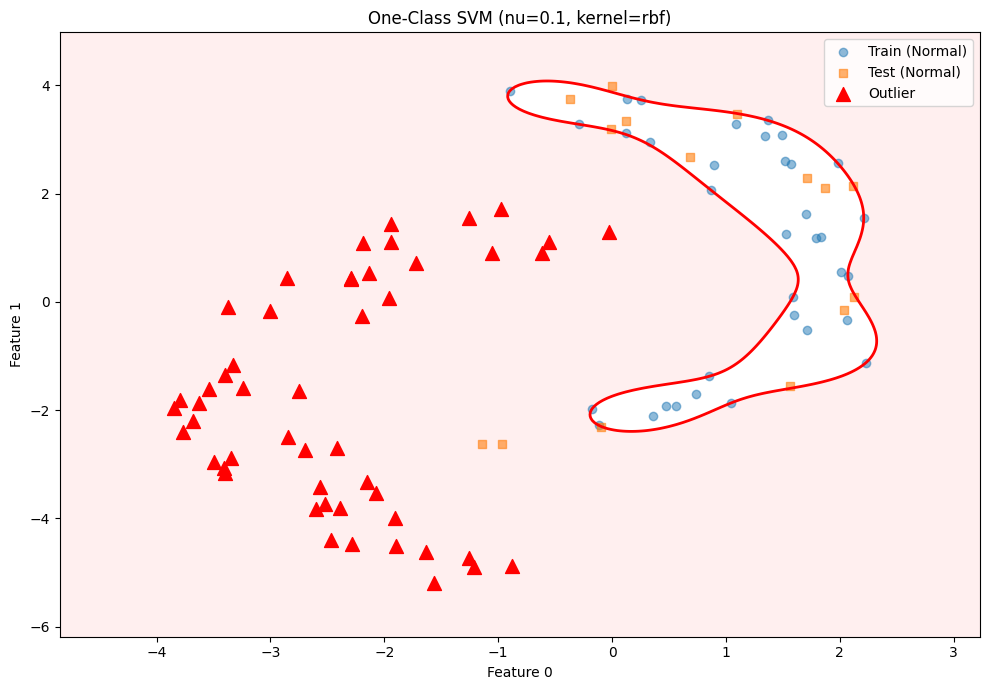

In [6]:
# Decision Boundary 시각화
xx, yy = np.meshgrid(np.linspace(X["0"].min()-1, X["0"].max()+1, 300),  
                     np.linspace(X["1"].min()-1, X["1"].max()+1, 300))
Z = oc_svm.decision_function(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"])) # 격자의 각 점이 정상 영역에서 얼마나 떨어져있는지 계산
Z = Z.reshape(xx.shape)  # 원래 격자 모양으로 복원

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)  # 이상치로 판단되는 영역을 옅은 빨강으로 채움
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")  # 정상/이상치를 가르는 경계선 그리기
plt.scatter(X_train["0"], X_train["1"], label="Train (Normal)", alpha=0.5)  # 학습에 사용한 정상 데이터
plt.scatter(X_test_normal["0"], X_test_normal["1"], label="Test (Normal)", marker="s", alpha=0.6)  # 테스트용 정상 데이터
plt.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")  # 이상치 데이터
plt.legend()
plt.title("One-Class SVM (nu=0.1, kernel=rbf)")
plt.xlabel("Feature 0"); plt.ylabel("Feature 1")
plt.tight_layout()
plt.show()

### 2-3) 성능 평가

In [7]:
# 분류 성능 평가 함수
def get_classscore(real, pred, pos_label=1):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred, pos_label=pos_label))
    print("Recall    : %.3f" % recall_score(real, pred, pos_label=pos_label))
    print("F1-score  : %.3f" % f1_score(real, pred, pos_label=pos_label))
    print()
    print("혼동행렬:")
    print(confusion_matrix(real, pred))

In [8]:
Y_pred = oc_svm.predict(X_test)
get_classscore(Y_test, Y_pred, pos_label=-1)

Accuracy  : 0.938
Precision : 0.926
Recall    : 1.000
F1-score  : 0.962

혼동행렬:
[[50  0]
 [ 4 11]]


---

## 3) nu 값에 따른 과적합/과소적합 확인

> **`nu` 파라미터**
> - `nu`가 작으면: Boundary가 넓어짐 → 과소적합
> - `nu`가 크면: Boundary가 좁아짐 → 과적합 (정상 데이터도 이상치로 분류되기 쉬움)
> - SVDD의 $C$와 반대 방향으로 작동함 (nu가 클수록 더 많은 정상 데이터가 이상치로 분류됨)

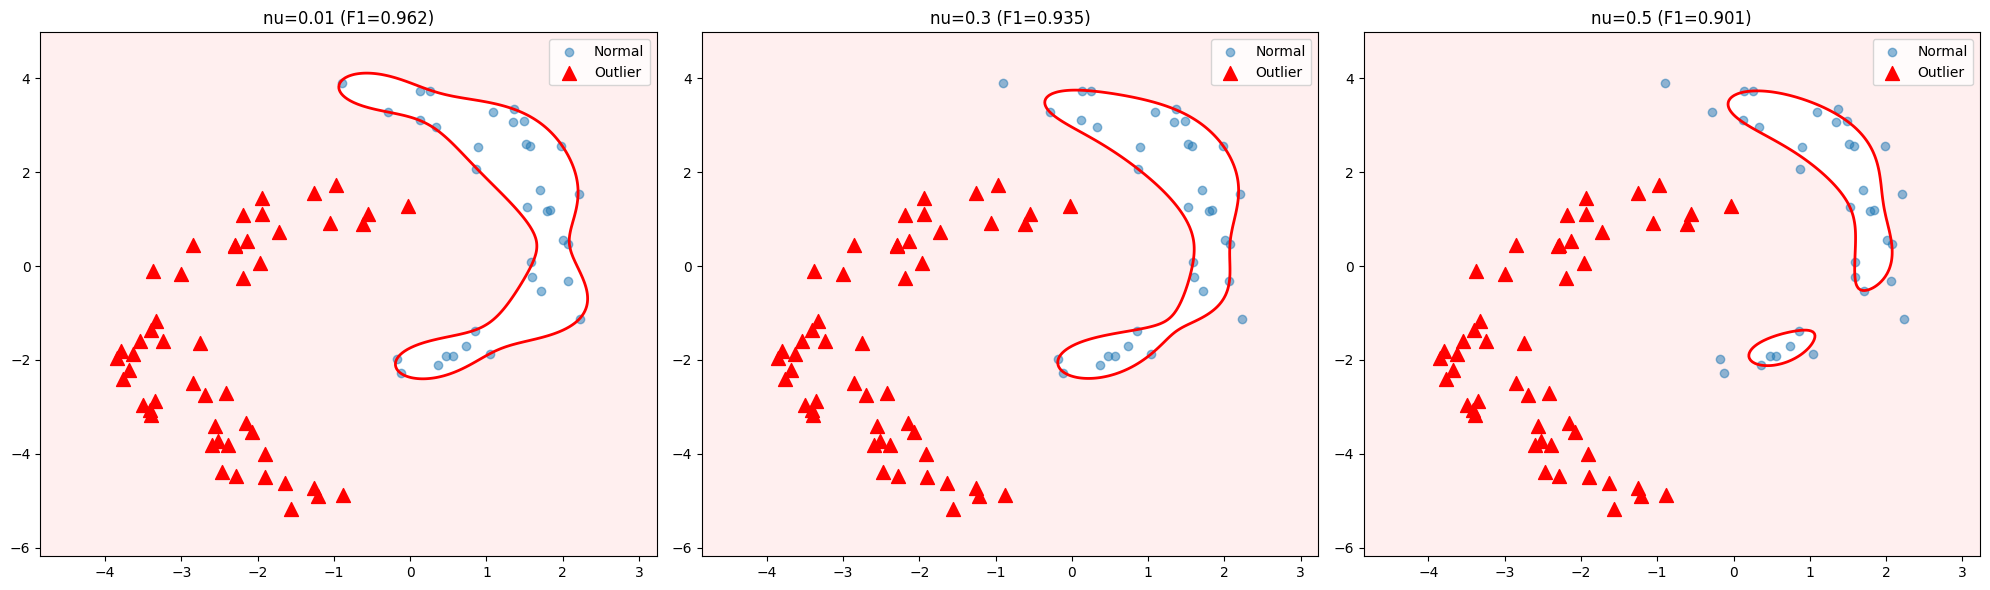

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
nu_values = [0.01, 0.3, 0.5]  

grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"]) 

for ax, nu in zip(axes, nu_values):
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train)

    Z = model.decision_function(grid_points).reshape(xx.shape) 

    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")
    ax.scatter(X_train["0"], X_train["1"], label="Normal", alpha=0.5)
    ax.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")

    pred = model.predict(X_test)
    f1 = f1_score(Y_test, pred, pos_label=-1)
    ax.set_title(f"nu={nu} (F1={f1:.3f})", pad=10)
    if ax is axes[0]:
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

fig.tight_layout(pad=2.0)
plt.show()

In [10]:
# nu 값에 따른 성능 변화
results = []
for nu in [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train)
    pred = model.predict(X_test)
    results.append({
        "nu": nu,
        "F1-score": round(f1_score(Y_test, pred, pos_label=-1), 3),
        "Recall": round(recall_score(Y_test, pred, pos_label=-1), 3),
        "Precision": round(precision_score(Y_test, pred, pos_label=-1), 3)
    })

pd.DataFrame(results)

,nu,F1-score,Recall,Precision
0,0.01,0.962,1.0,0.926
1,0.05,0.962,1.0,0.926
2,0.10,0.962,1.0,0.926
3,0.15,0.962,1.0,0.926
4,0.20,0.962,1.0,0.926
5,0.30,0.935,1.0,0.877
6,0.50,0.901,1.0,0.820


---

## 4) Vibe Coding 실습

**[과제 1]** 지수는 nu 값에 따른 Boundary 변화는 확인했지만, gamma 파라미터도 Boundary 모양에 큰 영향을 준다는 것을 알게 되었습니다. gamma를 "auto"가 아니라 직접 여러 값으로 바꿔보면 어떤 차이가 나는지 궁금합니다. AI와 상의하여 gamma 값을 [0.01, 0.1, 1, 10]으로 바꿔가며 Boundary를 시각화하고 nu와 gamma가 각각 어떤 역할을 하는지 정리해 보세요.

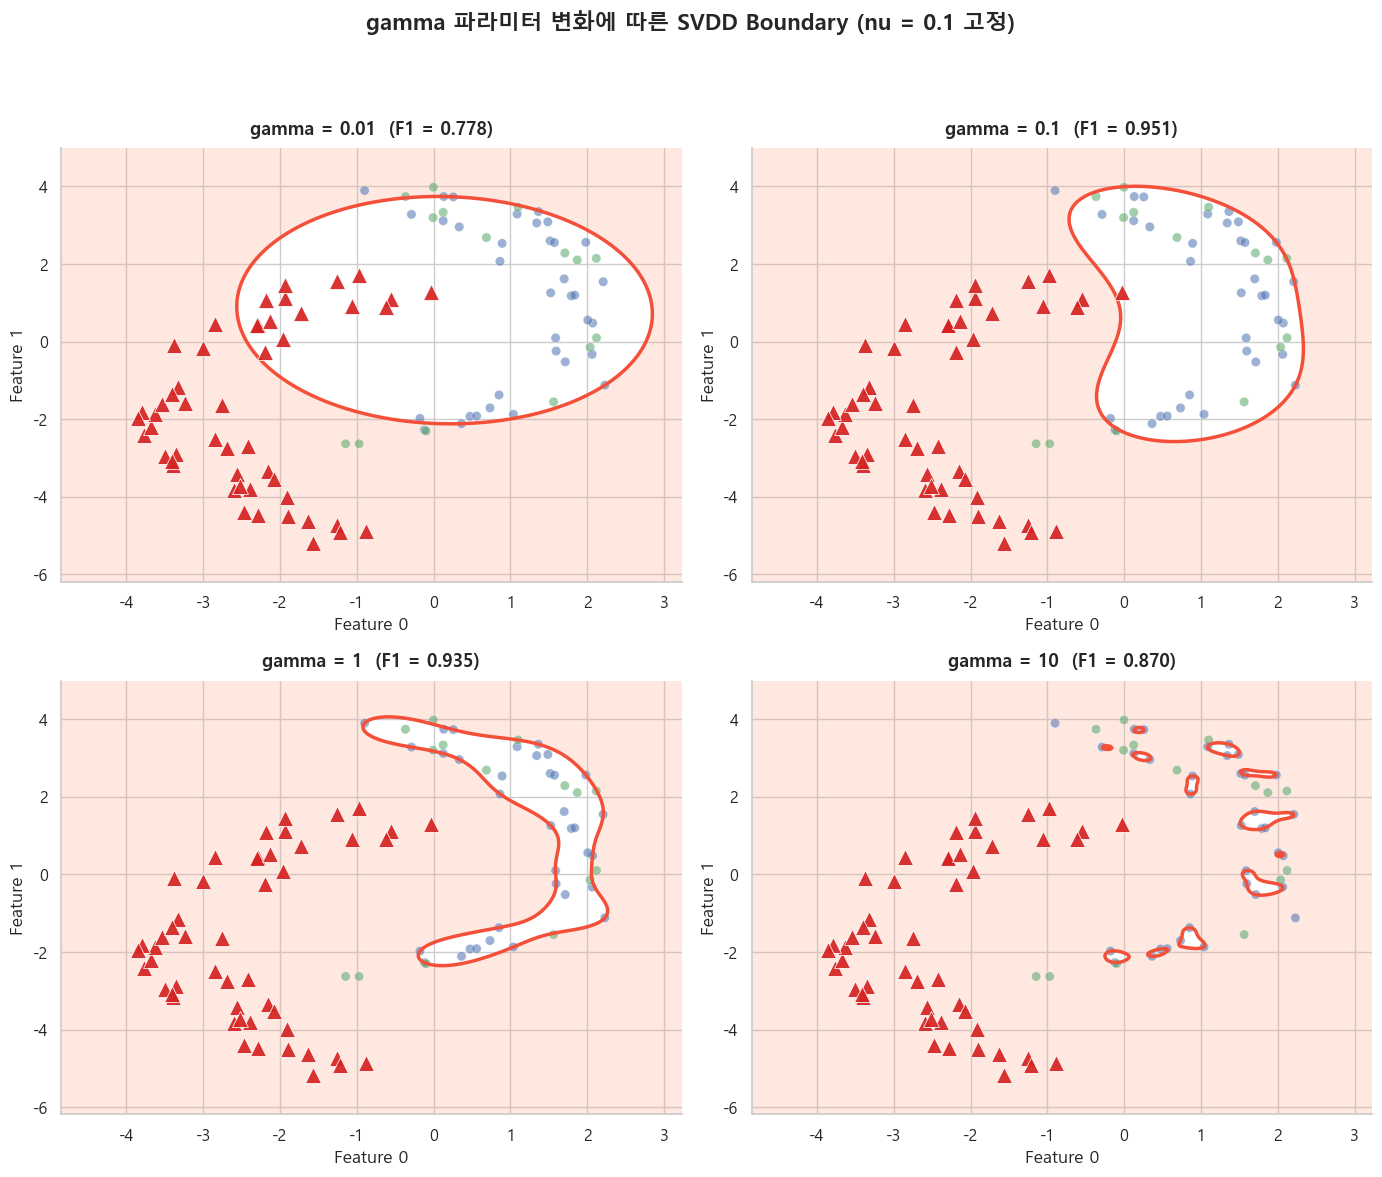

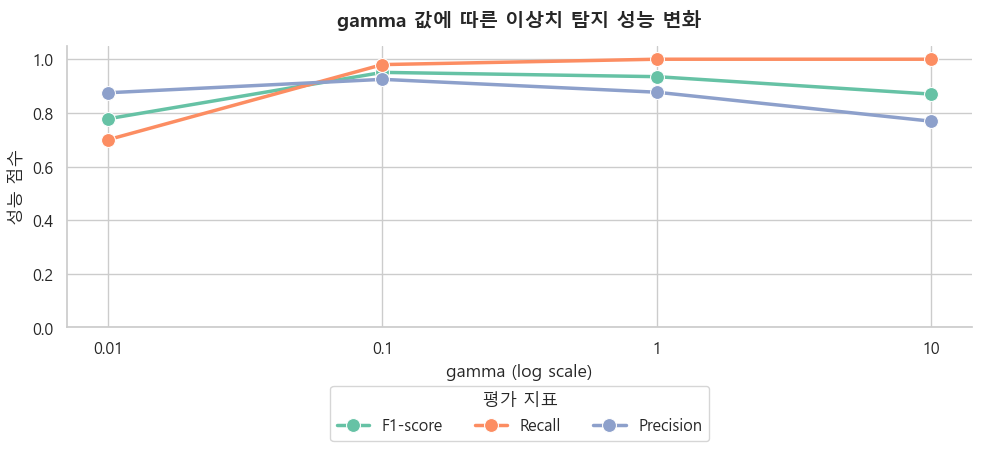

,gamma,F1-score,Recall,Precision
0,0.01,0.778,0.70,0.875
1,0.10,0.951,0.98,0.925
2,1.00,0.935,1.00,0.877
3,10.00,0.870,1.00,0.769


In [14]:
# ===== [과제 1] gamma 파라미터 변화에 따른 Boundary 시각화 =====

import seaborn as sns
import matplotlib.font_manager as fm


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    try:
        _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
        _available = {f.name for f in fm.fontManager.ttflist}
        for _font in _korean_fonts:
            if _font in _available:
                plt.rcParams["font.family"] = _font
                break
        else:
            print("[경고] 한글 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")
        plt.rcParams["axes.unicode_minus"] = False
    except Exception as e:
        print(f"[경고] 한글 폰트 설정 중 오류 발생: {e}. 기본 폰트를 사용합니다.")
        plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
setup_korean_font()

NU_FIXED = 0.1
GAMMA_VALUES = [0.01, 0.1, 1, 10]

xx, yy = np.meshgrid(
    np.linspace(X["0"].min() - 1, X["0"].max() + 1, 300),
    np.linspace(X["1"].min() - 1, X["1"].max() + 1, 300),
)
grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"])

scatter_df = pd.concat([
    X_train.assign(유형="학습 (정상)", 클래스="정상"),
    X_test_normal.assign(유형="테스트 (정상)", 클래스="정상"),
    X_outlier.assign(유형="이상치", 클래스="이상치"),
], ignore_index=True)

gamma_results = []
deep_colors = sns.color_palette("deep")
boundary_fill = sns.color_palette("Reds")[1]
boundary_line = sns.color_palette("Reds")[3]
outlier_color = sns.color_palette("Reds")[4]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, gamma in zip(axes, GAMMA_VALUES):
    model = OneClassSVM(kernel="rbf", gamma=gamma, nu=NU_FIXED)
    model.fit(X_train)

    Z = model.decision_function(grid_points).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=[boundary_fill], alpha=0.28)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2.5, colors=[boundary_line])

    sns.scatterplot(
        data=scatter_df[scatter_df["클래스"] == "정상"],
        x="0", y="1", hue="유형", ax=ax,
        palette={"학습 (정상)": deep_colors[0], "테스트 (정상)": deep_colors[2]},
        alpha=0.55, s=45, edgecolor="white", linewidth=0.4, legend=False,
    )
    sns.scatterplot(
        data=scatter_df[scatter_df["클래스"] == "이상치"],
        x="0", y="1", ax=ax,
        color=outlier_color, marker="^", s=130, alpha=0.92,
        edgecolor="white", linewidth=0.6, legend=False, zorder=5,
    )

    pred = model.predict(X_test)
    f1 = f1_score(Y_test, pred, pos_label=-1)
    gamma_results.append({
        "gamma": gamma,
        "F1-score": round(f1, 3),
        "Recall": round(recall_score(Y_test, pred, pos_label=-1), 3),
        "Precision": round(precision_score(Y_test, pred, pos_label=-1), 3),
    })

    ax.set_title(f"gamma = {gamma}  (F1 = {f1:.3f})", fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
    sns.despine(ax=ax)

fig.suptitle(
    f"gamma 파라미터 변화에 따른 SVDD Boundary (nu = {NU_FIXED} 고정)",
    fontsize=16, fontweight="bold", y=0.98,
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# gamma별 성능 변화 (seaborn lineplot)
gamma_df = pd.DataFrame(gamma_results)
metric_df = gamma_df.melt(
    id_vars="gamma",
    value_vars=["F1-score", "Recall", "Precision"],
    var_name="지표",
    value_name="점수",
)

fig2, ax2 = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=metric_df, x="gamma", y="점수", hue="지표", marker="o",
    linewidth=2.5, markersize=10, ax=ax2, palette="Set2",
)
ax2.set_xscale("log")
ax2.set_xlabel("gamma (log scale)")
ax2.set_ylabel("성능 점수")
ax2.set_title("gamma 값에 따른 이상치 탐지 성능 변화", fontsize=14, fontweight="bold", pad=14)
ax2.set_xticks(GAMMA_VALUES)
ax2.set_xticklabels([str(g) for g in GAMMA_VALUES])
ax2.set_ylim(0, 1.05)
ax2.legend(
    title="평가 지표", loc="upper center",
    bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=True,
)
sns.despine(ax=ax2)
fig2.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

display(gamma_df)

#### nu vs gamma 파라미터 역할 정리

| 파라미터 | 역할 | 값이 작을 때 | 값이 클 때 |
|:---:|:---|:---|:---|
| **nu** | 이상치로 허용할 **비율 상한** (경계의 크기) | 경계가 **넓어짐** → 정상을 이상치로 오분류 ↓, 이상치 미탐 ↑ (**과소적합**) | 경계가 **좁아짐** → 이상치 탐지 ↑, 정상 오분류 ↑ (**과적합**) |
| **gamma** | RBF 커널의 **영향 반경** (경계의 곡률·복잡도) | 영향 범위가 넓어 **부드럽고 큰** 경계 (**과소적합** 경향) | 학습점 주변만 반영해 **울퉁불퉁·좁은** 경계 (**과적합** 경향) |

**실습에서 관찰한 gamma 변화**
- `gamma = 0.01` : 경계가 넓고 매끄러움 → 이상치(빨간 △) 일부를 놓칠 수 있음
- `gamma = 10` : 정상 데이터 주변에 작은 '섬' 형태 경계 → 정상도 이상치로 분류될 수 있음

> **요약**: `nu`는 *"얼마나 많이 이상치로 허용할지"*, `gamma`는 *"경계를 얼마나 세밀하게 그릴지"*를 조절한다. 두 파라미터 모두 너무 작으면 과소적합, 너무 크면 과적합 경향이 나타난다.

#### [과제 1-2] Optuna로 nu · gamma 최적값 탐색 (TPE vs GP)

| 방법 | 샘플러 | 목적함수 | 특징 |
|:---|:---|:---|:---|
| **TPE** | `TPESampler(multivariate=True, group=True)` | F1-score 단일 | nu–gamma 상관관계 모델링, F1 최대화 |
| **GP** | `GPSampler` | F1 · Recall · Precision **다중** | 가우시안 프로세스 기반, Pareto 최적해 탐색 |

공통 설정: `suggest_float(..., log=True)` (gamma), `enqueue_trial()` 워ーム스타트, 60 Trials

Best trial: 11. Best value: 0.980392: 100%|██████████| 60/60 [00:18<00:00,  3.25it/s]


[TPE] F1 단일 목적 최적화 결과
Best F1-score : 0.9804
Best nu       : 0.057344
Best gamma    : 0.154609
Recall        : 1.0000
Precision     : 0.9615


 17%|█▋        | 10/60 [00:03<00:18,  2.64it/s]100%|██████████| 60/60 [01:32<00:00,  1.54s/it]


[GP] F1 · Recall · Precision 다중 목적 최적화 결과
Pareto 최적 Trial 수 : 5
Best F1 (Pareto)     : 0.9804
  → Recall           : 1.0000
  → Precision        : 0.9615
  → nu               : 0.010000
  → gamma            : 0.214201

TPE vs GP 성능 · 파라미터 비교


,방법,nu,gamma,F1-score,Recall,Precision
0,TPE (F1 단일),0.0573,0.1546,0.9804,1.0,0.9615
1,"GP (Pareto, F1 최대)",0.0100,0.2142,0.9804,1.0,0.9615



[GP] Pareto Front (5개 Trial)


,Trial,nu,gamma,F1-score,Recall,Precision
0,11,0.01,0.2142,0.9804,1.0,0.9615
1,20,0.01,0.2628,0.9804,1.0,0.9615
2,21,0.01,0.2324,0.9804,1.0,0.9615
3,47,0.01,0.1655,0.9804,1.0,0.9615
4,57,0.01,0.3040,0.9804,1.0,0.9615



[TPE] 파라미터 중요도 (F1 기준):
  gamma  : 0.969
  nu     : 0.031


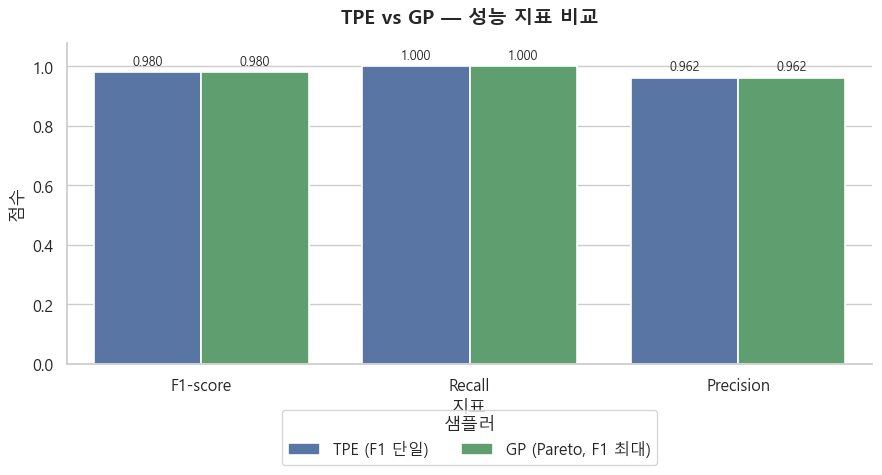

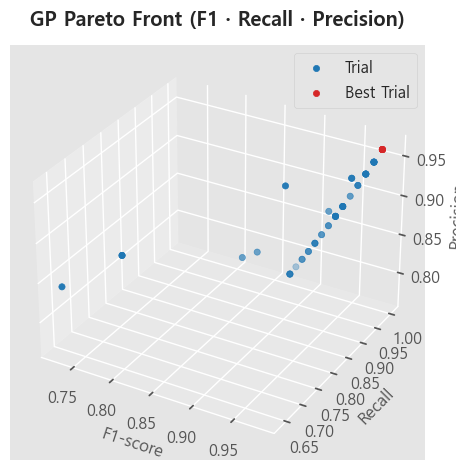

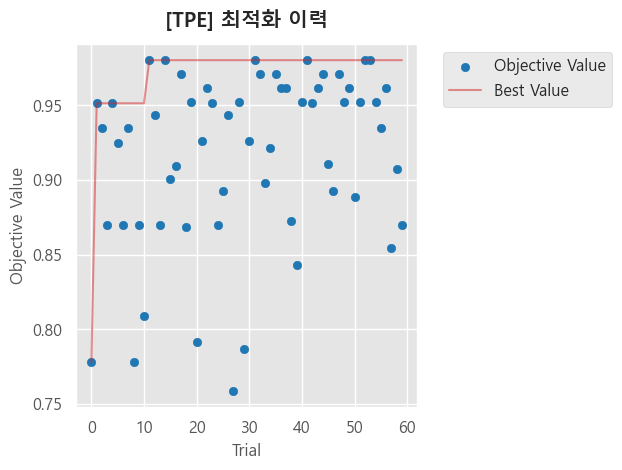

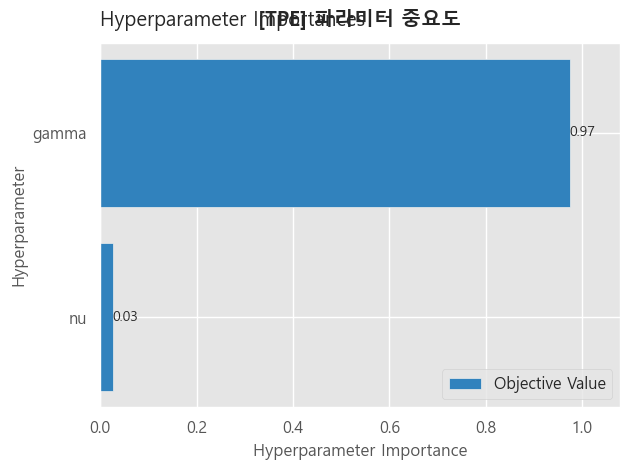

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

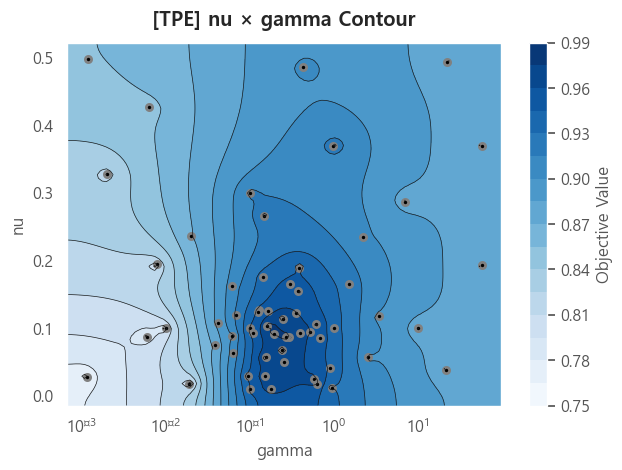

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

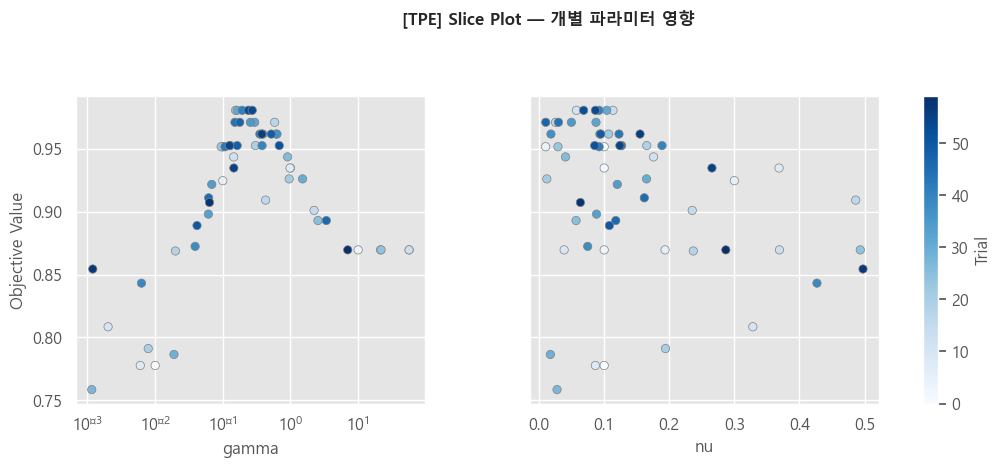

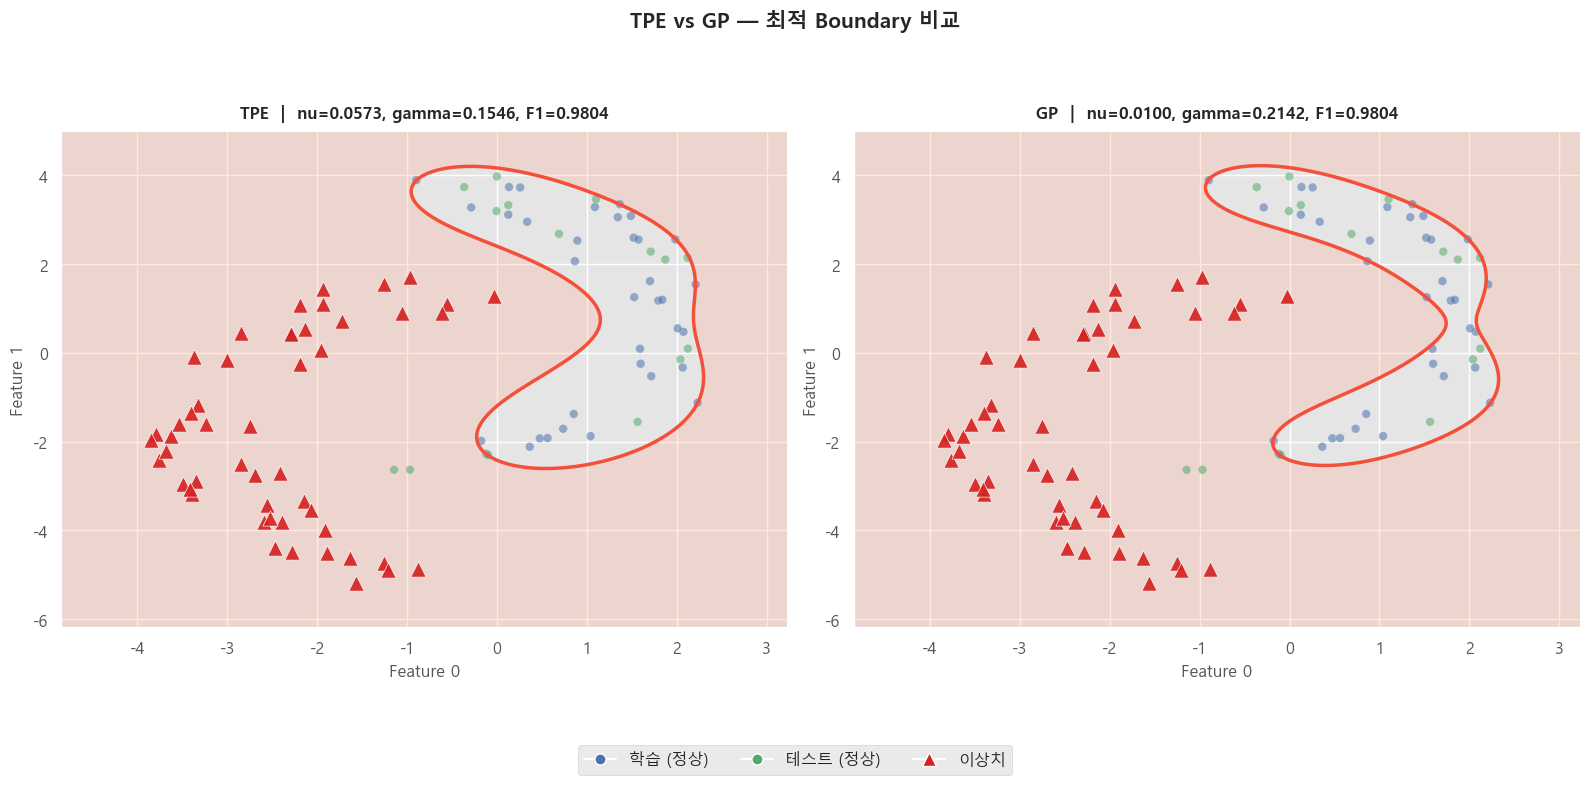

In [21]:
# ===== [과제 1-2] Optuna 하이퍼파라미터 최적화 — TPE vs GP =====

import warnings

import optuna
import optuna.importance as oimp
import optuna.visualization.matplotlib as optuna_vis
from matplotlib.lines import Line2D
from optuna.samplers import GPSampler, TPESampler

warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 60
WARM_START = [
    {"nu": 0.1, "gamma": 0.01},
    {"nu": 0.1, "gamma": 0.1},
    {"nu": 0.1, "gamma": 1.0},
    {"nu": 0.1, "gamma": 10.0},
    {"nu": 0.01, "gamma": 0.1},
    {"nu": 0.3, "gamma": 0.1},
]


def _evaluate_svdd(nu: float, gamma: float) -> tuple[float, float, float]:
    model = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu)
    model.fit(X_train)
    pred = model.predict(X_test)
    return (
        f1_score(Y_test, pred, pos_label=-1),
        recall_score(Y_test, pred, pos_label=-1),
        precision_score(Y_test, pred, pos_label=-1),
    )


def objective_f1(trial: optuna.Trial) -> float:
    """TPE: F1-score 단일 목적."""
    nu = trial.suggest_float("nu", 0.01, 0.5)
    gamma = trial.suggest_float("gamma", 1e-3, 100.0, log=True)
    f1, recall, precision = _evaluate_svdd(nu, gamma)
    trial.set_user_attr("recall", recall)
    trial.set_user_attr("precision", precision)
    return f1


def objective_multi(trial: optuna.Trial) -> tuple[float, float, float]:
    """GP: F1, Recall, Precision 다중 목적."""
    nu = trial.suggest_float("nu", 0.01, 0.5)
    gamma = trial.suggest_float("gamma", 1e-3, 100.0, log=True)
    return _evaluate_svdd(nu, gamma)


# ── 1) TPE — F1 단일 목적 ──
study_tpe = optuna.create_study(
    study_name="svdd_tpe_f1",
    direction="maximize",
    sampler=TPESampler(multivariate=True, group=True, seed=42, n_startup_trials=10),
)
for params in WARM_START:
    study_tpe.enqueue_trial(params)
study_tpe.optimize(objective_f1, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True)

best_tpe = study_tpe.best_trial
print("=" * 55)
print("[TPE] F1 단일 목적 최적화 결과")
print("=" * 55)
print(f"Best F1-score : {best_tpe.value:.4f}")
print(f"Best nu       : {best_tpe.params['nu']:.6f}")
print(f"Best gamma    : {best_tpe.params['gamma']:.6f}")
print(f"Recall        : {best_tpe.user_attrs['recall']:.4f}")
print(f"Precision     : {best_tpe.user_attrs['precision']:.4f}")

# ── 2) GP — F1 · Recall · Precision 다중 목적 ──
study_gp = optuna.create_study(
    study_name="svdd_gp_multi",
    directions=["maximize", "maximize", "maximize"],
    sampler=GPSampler(seed=42, n_startup_trials=10),
)
for params in WARM_START:
    study_gp.enqueue_trial(params)
study_gp.optimize(objective_multi, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True)

pareto_gp = study_gp.best_trials
best_gp_f1 = max(pareto_gp, key=lambda t: t.values[0])

print("\n" + "=" * 55)
print("[GP] F1 · Recall · Precision 다중 목적 최적화 결과")
print("=" * 55)
print(f"Pareto 최적 Trial 수 : {len(pareto_gp)}")
print(f"Best F1 (Pareto)     : {best_gp_f1.values[0]:.4f}")
print(f"  → Recall           : {best_gp_f1.values[1]:.4f}")
print(f"  → Precision        : {best_gp_f1.values[2]:.4f}")
print(f"  → nu               : {best_gp_f1.params['nu']:.6f}")
print(f"  → gamma            : {best_gp_f1.params['gamma']:.6f}")

# ── 3) TPE vs GP 비교 ──
compare_df = pd.DataFrame([
    {
        "방법": "TPE (F1 단일)",
        "nu": best_tpe.params["nu"],
        "gamma": best_tpe.params["gamma"],
        "F1-score": best_tpe.value,
        "Recall": best_tpe.user_attrs["recall"],
        "Precision": best_tpe.user_attrs["precision"],
    },
    {
        "방법": "GP (Pareto, F1 최대)",
        "nu": best_gp_f1.params["nu"],
        "gamma": best_gp_f1.params["gamma"],
        "F1-score": best_gp_f1.values[0],
        "Recall": best_gp_f1.values[1],
        "Precision": best_gp_f1.values[2],
    },
])
print("\n" + "=" * 55)
print("TPE vs GP 성능 · 파라미터 비교")
print("=" * 55)
display(compare_df.round(4))

pareto_df = (
    pd.DataFrame([
        {
            "Trial": t.number,
            "nu": t.params["nu"],
            "gamma": t.params["gamma"],
            "F1-score": t.values[0],
            "Recall": t.values[1],
            "Precision": t.values[2],
        }
        for t in pareto_gp
    ])
    .sort_values("F1-score", ascending=False)
    .reset_index(drop=True)
)
print(f"\n[GP] Pareto Front ({len(pareto_df)}개 Trial)")
display(pareto_df.round(4))

param_importance = oimp.get_param_importances(study_tpe)
print("\n[TPE] 파라미터 중요도 (F1 기준):")
for name, score in param_importance.items():
    print(f"  {name:6s} : {score:.3f}")

# ── 4) seaborn 비교 시각화 ──
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
setup_korean_font()

metric_compare = compare_df.melt(
    id_vars="방법", value_vars=["F1-score", "Recall", "Precision"],
    var_name="지표", value_name="점수",
)
fig_cmp, ax_cmp = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=metric_compare, x="지표", y="점수", hue="방법",
    ax=ax_cmp, palette={"TPE (F1 단일)": "#4C72B0", "GP (Pareto, F1 최대)": "#55A868"},
    edgecolor="white", linewidth=1.2,
)
ax_cmp.set_ylim(0, 1.08)
ax_cmp.set_title("TPE vs GP — 성능 지표 비교", fontsize=14, fontweight="bold", pad=14)
for container in ax_cmp.containers:
    ax_cmp.bar_label(container, fmt="%.3f", fontsize=9, padding=3)
ax_cmp.legend(
    title="샘플러", loc="upper center",
    bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True,
)
sns.despine(ax=ax_cmp)
fig_cmp.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# GP Pareto Front (3D)
ax_pareto = optuna_vis.plot_pareto_front(
    study_gp, target_names=["F1-score", "Recall", "Precision"],
)
ax_pareto.set_title("GP Pareto Front (F1 · Recall · Precision)", fontweight="bold", pad=14)
ax_pareto.figure.tight_layout()
plt.show()

# ── 5) TPE 상세 시각화 ──
trials_tpe_df = (
    study_tpe.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
)

ax = optuna_vis.plot_optimization_history(study_tpe)
ax.set_title("[TPE] 최적화 이력", fontweight="bold", pad=12)
ax.figure.tight_layout()
plt.show()

ax = optuna_vis.plot_param_importances(study_tpe)
ax.set_title("[TPE] 파라미터 중요도", fontweight="bold", pad=12)
ax.figure.tight_layout()
plt.show()

ax = optuna_vis.plot_contour(study_tpe, params=["nu", "gamma"])
ax.set_title("[TPE] nu × gamma Contour", fontweight="bold", pad=12)
ax.figure.tight_layout()
plt.show()

slice_axes = np.atleast_1d(optuna_vis.plot_slice(study_tpe, params=["nu", "gamma"]))
slice_fig = slice_axes[0].figure
slice_fig.set_size_inches(11, 4.8)
_plot_ids = {id(a) for a in slice_axes.ravel()}
_cbar_ax = next(ax for ax in slice_fig.axes if id(ax) not in _plot_ids)
slice_fig.subplots_adjust(top=0.78, bottom=0.14, left=0.07, right=0.80, wspace=0.30)
_cbar_ax.set_position([0.84, 0.14, 0.025, 0.64])
slice_fig.suptitle("[TPE] Slice Plot — 개별 파라미터 영향", fontweight="bold", y=0.96)
plt.show()

# ── 6) TPE vs GP Boundary 나란히 비교 ──
xx, yy = np.meshgrid(
    np.linspace(X["0"].min() - 1, X["0"].max() + 1, 300),
    np.linspace(X["1"].min() - 1, X["1"].max() + 1, 300),
)
grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"])
scatter_df = pd.concat([
    X_train.assign(유형="학습 (정상)"),
    X_test_normal.assign(유형="테스트 (정상)"),
    X_outlier.assign(유형="이상치"),
], ignore_index=True)

candidates = [
    ("TPE", best_tpe.params["nu"], best_tpe.params["gamma"], best_tpe.value),
    ("GP", best_gp_f1.params["nu"], best_gp_f1.params["gamma"], best_gp_f1.values[0]),
]

fig_bd, axes_bd = plt.subplots(1, 2, figsize=(16, 7))
for ax, (label, nu, gamma, f1) in zip(axes_bd, candidates):
    model = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu)
    model.fit(X_train)
    Z = model.decision_function(grid_points).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=[sns.color_palette("Reds")[1]], alpha=0.28)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2.5, colors=[sns.color_palette("Reds")[3]])
    sns.scatterplot(
        data=scatter_df[scatter_df["유형"] != "이상치"],
        x="0", y="1", hue="유형", ax=ax,
        palette={"학습 (정상)": sns.color_palette("deep")[0], "테스트 (정상)": sns.color_palette("deep")[2]},
        alpha=0.55, s=40, edgecolor="white", linewidth=0.3, legend=False,
    )
    sns.scatterplot(
        data=scatter_df[scatter_df["유형"] == "이상치"],
        x="0", y="1", ax=ax, color=sns.color_palette("Reds")[4],
        marker="^", s=120, alpha=0.92, edgecolor="white", linewidth=0.5, legend=False, zorder=5,
    )
    ax.set_title(f"{label}  |  nu={nu:.4f}, gamma={gamma:.4f}, F1={f1:.4f}",
                 fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
    sns.despine(ax=ax)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=sns.color_palette("deep")[0], markersize=8, label="학습 (정상)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=sns.color_palette("deep")[2], markersize=8, label="테스트 (정상)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=sns.color_palette("Reds")[4], markersize=10, label="이상치"),
]
fig_bd.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)
fig_bd.suptitle("TPE vs GP — 최적 Boundary 비교", fontsize=15, fontweight="bold", y=1.02)
fig_bd.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()


#### TPE vs GP 비교 해석

| 항목 | TPE (F1 단일) | GP (F1·Recall·Precision 다중) |
|:---|:---|:---|
| **탐색 방식** | F1 하나만 최대화 → 단일 최적해 | 3개 지표 동시 최대화 → **Pareto Front** |
| **장점** | 목표가 명확할 때 빠르고 직관적 | Recall·Precision **트레이드오프**를 함께 고려 |
| **파라미터** | F1 최적 nu, gamma 1세트 | Pareto 위 여러 (nu, gamma) 후보 제공 |

> **실험 관찰**: 두 방법 모두 F1 ≈ 0.980, Recall = 1.0, Precision ≈ 0.962 수준의 해를 찾을 수 있었으나, **최적 nu·gamma 값은 다를 수 있음** (목적함수 설계 차이). GP는 Pareto Front를 통해 "Recall을 유지하면서 Precision을 더 올릴 수 있는가?" 같은 다목적 의사결정에 유리하다.